In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.preprocessing import LabelEncoder
from IPython.display import display

# Настройка стилей
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_style("whitegrid")
sns.set_palette("husl")
np.random.seed(42)

In [9]:
# Загрузка данных
df = pd.read_csv('Banking_Transactions_USA_2023_2024.csv')
print(f"Размер датасета: {df.shape}")
print("\nИнформация о признаках:")
print(df.info())
print("\nПервые 3 строки:")
display(df.head(3))

Размер датасета: (5389, 20)

Информация о признаках:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5389 entries, 0 to 5388
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Transaction_ID           5389 non-null   object 
 1   Account_Number           5389 non-null   object 
 2   Transaction_Date         5389 non-null   object 
 3   Transaction_Amount       5389 non-null   float64
 4   Merchant_Name            5389 non-null   object 
 5   Transaction_Type         5389 non-null   object 
 6   Category                 5389 non-null   object 
 7   City                     5389 non-null   object 
 8   Country                  5389 non-null   object 
 9   Payment_Method           5389 non-null   object 
 10  Customer_Age             5389 non-null   int64  
 11  Customer_Gender          5389 non-null   object 
 12  Customer_Occupation      5389 non-null   object 
 13  Customer_Income          

,Transaction_ID,Account_Number,Transaction_Date,Transaction_Amount,Merchant_Name,Transaction_Type,Category,City,Country,Payment_Method,Customer_Age,Customer_Gender,Customer_Occupation,Customer_Income,Account_Balance,Transaction_Status,Fraud_Flag,Discount_Applied,Loyalty_Points_Earned,Transaction_Description
0,bdd640fb-0667-4ad1-9c80-317fa3b1799d,IUPM04409079772781,2023-11-05 15:54:38,3198.94,Houston Group,Debit,Transport,Phoenix,USA,Online Transfer,55,Others,Quality manager,80466.03,350.28,Failed,No,True,304,Recently company detail form range a.
1,23b8c1e9-3924-46de-beb1-3b9046685257,BLAT22216107051843,2024-04-21 22:21:55,129.93,Anderson-Phillips,Credit,Grocery,Philadelphia,USA,Debit Card,26,Others,Civil Service fast streamer,145574.25,9797.81,Pending,Yes,False,383,Anything son baby power heart will not up.
2,bd9c66b3-ad3c-4d6d-9a3d-1fa7bc8960a9,UTXA55295806601382,2023-07-17 13:25:56,1378.77,Jensen Group,Credit,Shopping,New York,USA,Debit Card,29,Others,"Pilot, airline",33447.18,12399.85,Failed,Yes,False,497,Form world around green bar environment pattern.


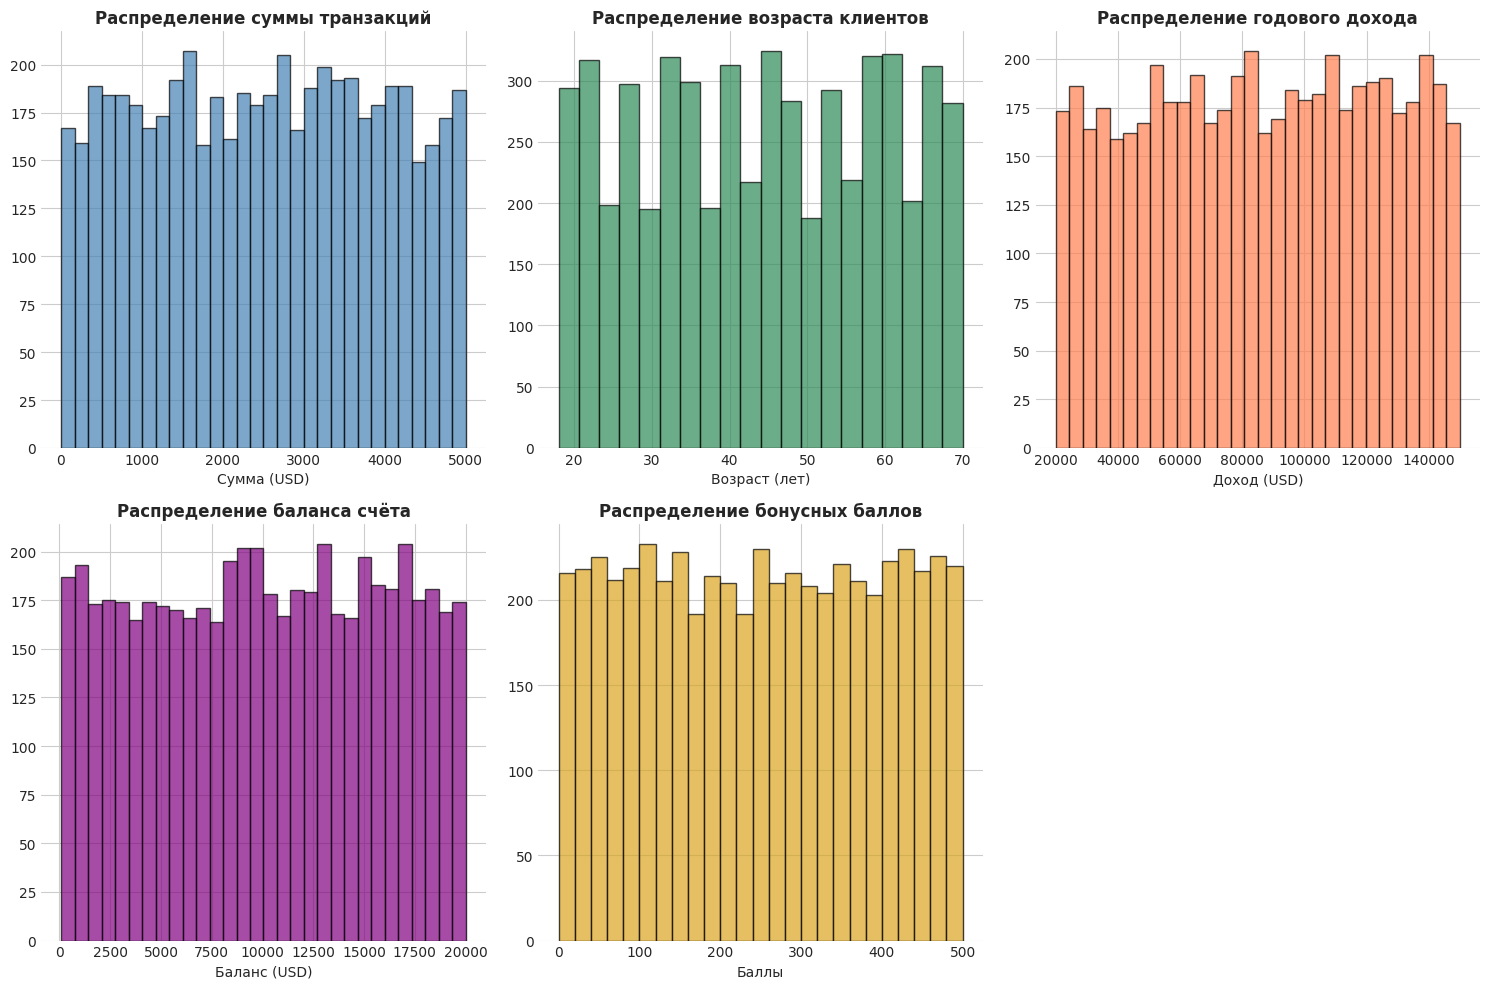

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

axes[0].hist(df['Transaction_Amount'], bins=30, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].set_title('Распределение суммы транзакций', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Сумма (USD)')

axes[1].hist(df['Customer_Age'], bins=20, edgecolor='black', alpha=0.7, color='seagreen')
axes[1].set_title('Распределение возраста клиентов', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Возраст (лет)')

axes[2].hist(df['Customer_Income'], bins=30, edgecolor='black', alpha=0.7, color='coral')
axes[2].set_title('Распределение годового дохода', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Доход (USD)')

axes[3].hist(df['Account_Balance'], bins=30, edgecolor='black', alpha=0.7, color='purple')
axes[3].set_title('Распределение баланса счёта', fontsize=12, fontweight='bold')
axes[3].set_xlabel('Баланс (USD)')

axes[4].hist(df['Loyalty_Points_Earned'], bins=25, edgecolor='black', alpha=0.7, color='goldenrod')
axes[4].set_title('Распределение бонусных баллов', fontsize=12, fontweight='bold')
axes[4].set_xlabel('Баллы')

fig.delaxes(axes[5])
plt.tight_layout()
plt.show()

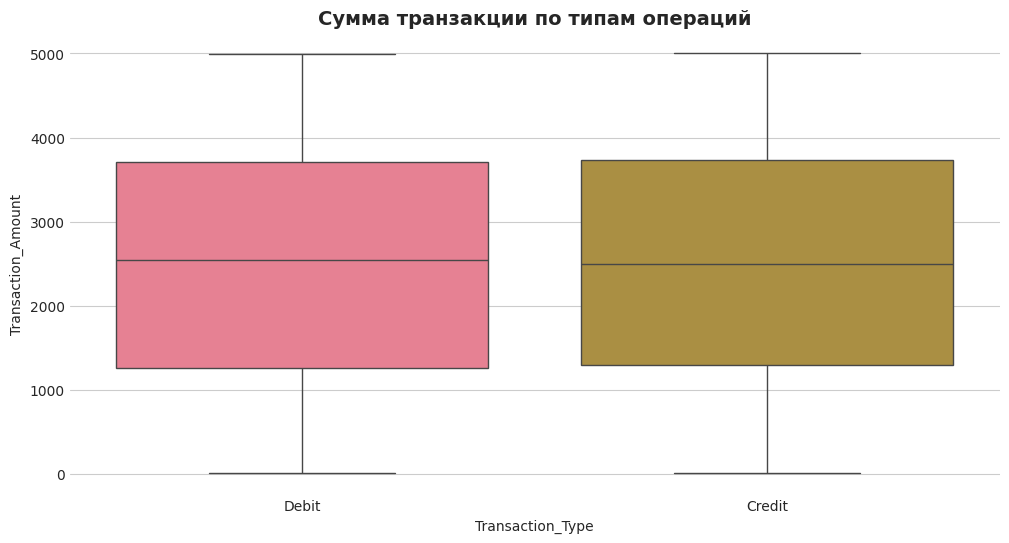

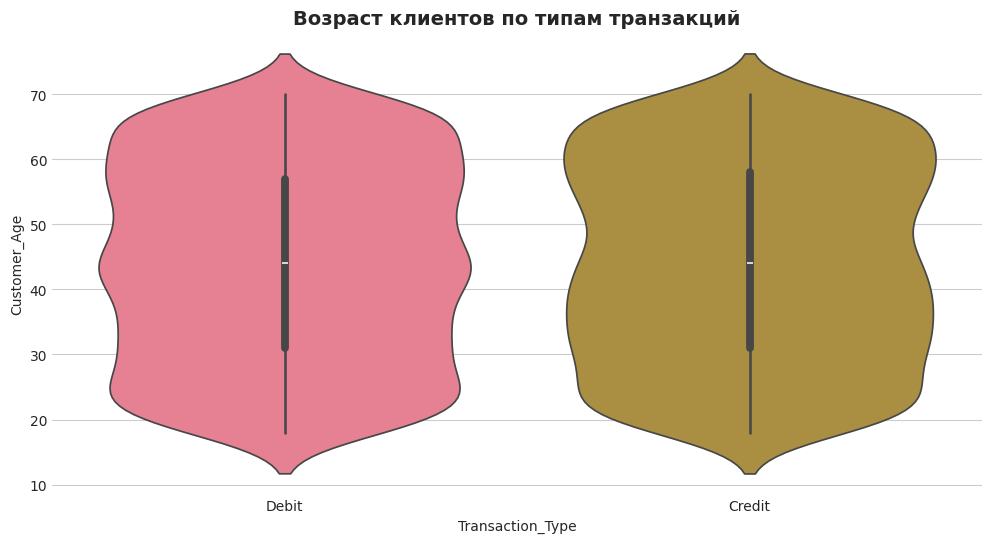

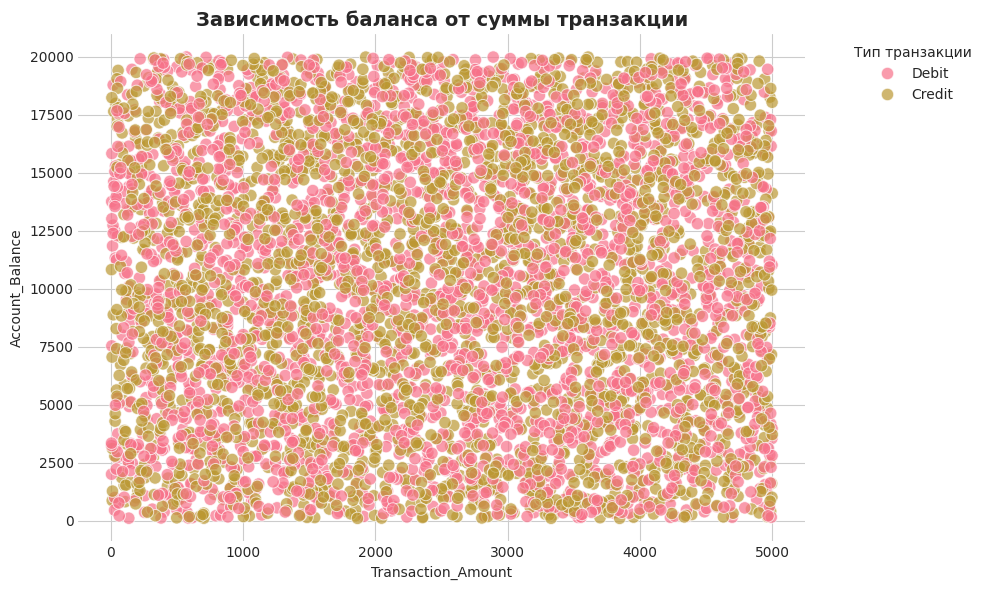

In [11]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='Transaction_Type', y='Transaction_Amount', hue='Transaction_Type', legend=False)
plt.title('Сумма транзакции по типам операций', fontsize=14, fontweight='bold')
plt.show()

plt.figure(figsize=(12, 6))
sns.violinplot(data=df, x='Transaction_Type', y='Customer_Age', hue='Transaction_Type', legend=False)
plt.title('Возраст клиентов по типам транзакций', fontsize=14, fontweight='bold')
plt.show()

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Transaction_Amount', y='Account_Balance', hue='Transaction_Type', alpha=0.7, s=80)
plt.title('Зависимость баланса от суммы транзакции', fontsize=14, fontweight='bold')
plt.legend(title='Тип транзакции', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

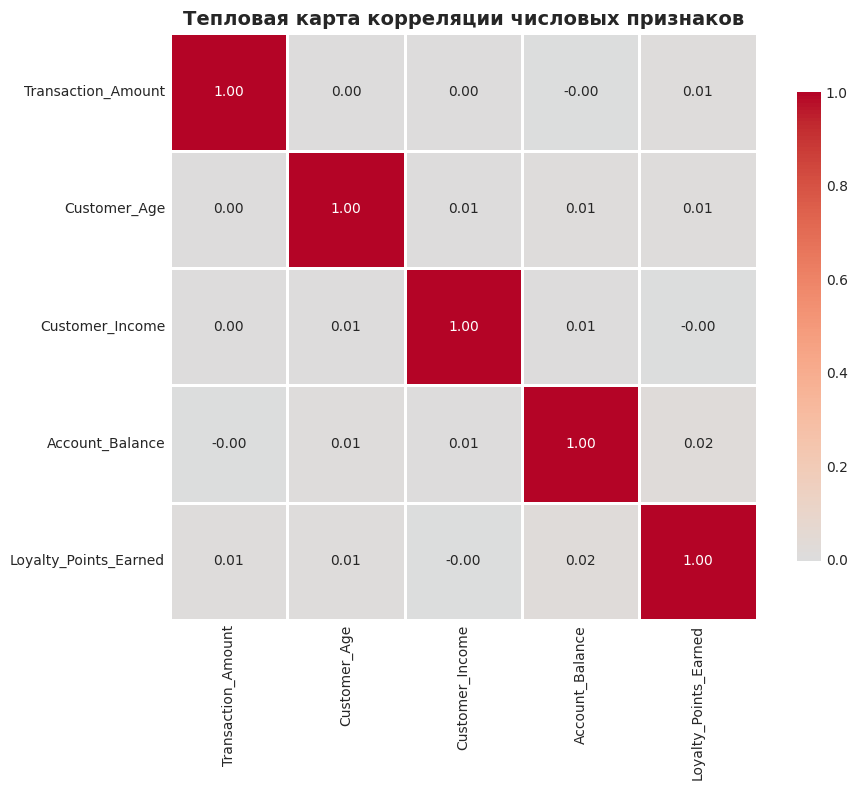

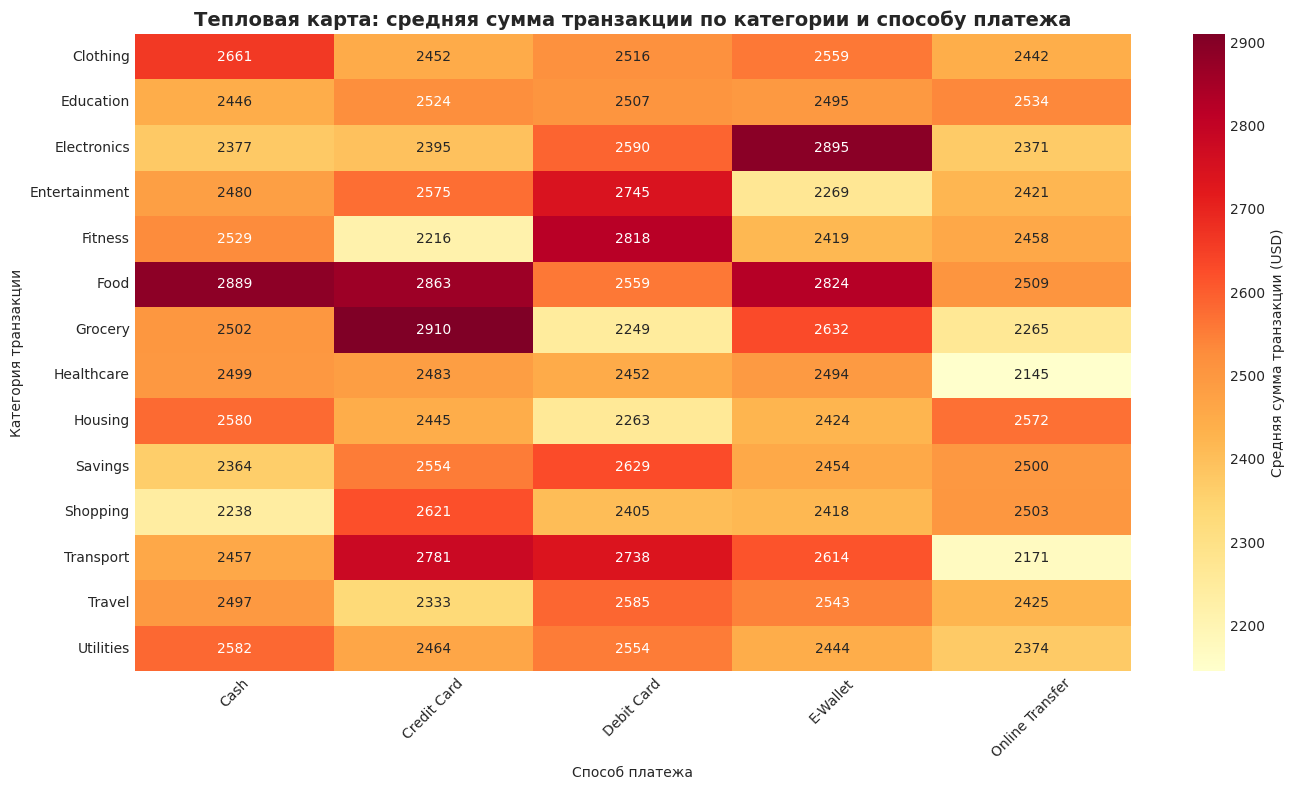

In [12]:
# 1. Корреляционная матрица числовых признаков
plt.figure(figsize=(10, 8))
numeric_cols = ['Transaction_Amount', 'Customer_Age', 'Customer_Income',
                'Account_Balance', 'Loyalty_Points_Earned']
corr_matrix = df[numeric_cols].corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=1, fmt='.2f',
            cbar_kws={'shrink': 0.8})
plt.title('Тепловая карта корреляции числовых признаков',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 2. Тепловая карта: средняя сумма транзакции по категории и способу платежа
pivot_table = df.pivot_table(values='Transaction_Amount',
                             index='Category',
                             columns='Payment_Method',
                             aggfunc='mean',
                             fill_value=0)

plt.figure(figsize=(14, 8))
sns.heatmap(pivot_table, annot=True, cmap='YlOrRd', fmt='.0f',
            cbar_kws={'label': 'Средняя сумма транзакции (USD)'})
plt.title('Тепловая карта: средняя сумма транзакции по категории и способу платежа',
          fontsize=14, fontweight='bold')
plt.xlabel('Способ платежа')
plt.ylabel('Категория транзакции')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [13]:
# 2.6 Дубликаты и 2.7 Выбросы (IQR)
print(f"Дубликатов: {df.duplicated().sum()}")
print(f"Дубликатов по Transaction_ID: {df.duplicated(subset=['Transaction_ID']).sum()}")

def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    return data[(data[column] < lower) | (data[column] > upper)], lower, upper

out_amt, lb_a, ub_a = detect_outliers_iqr(df, 'Transaction_Amount')
out_inc, lb_i, ub_i = detect_outliers_iqr(df, 'Customer_Income')

print(f"Выбросы Amount: {len(out_amt)} ({len(out_amt)/len(df)*100:.2f}%)")
print(f"Выбросы Income: {len(out_inc)} ({len(out_inc)/len(df)*100:.2f}%)")

Дубликатов: 0
Дубликатов по Transaction_ID: 0
Выбросы Amount: 0 (0.00%)
Выбросы Income: 0 (0.00%)


In [14]:

# 2.8 Условная фильтрация
filter1 = df[(df['Fraud_Flag'] == 1) & (df['Transaction_Amount'] > 1000)]
filter2 = df[(df['Customer_Income'] > 150000) & (df['Category'] == 'Electronics')]
filter3 = df[(df['Transaction_Status'] == 'Success') & (df['Discount_Applied'] == True) & (df['Category'] == 'Food')]

print(f"Фильтр 1 (Fraud > 1000$): {len(filter1)}")
print(f"Фильтр 2 (Income > 150k & Electronics): {len(filter2)}")
print(f"Фильтр 3 (Success & Discount & Food): {len(filter3)}")

Фильтр 1 (Fraud > 1000$): 0
Фильтр 2 (Income > 150k & Electronics): 0
Фильтр 3 (Success & Discount & Food): 63


Сумма транзакции:
  Нижняя граница: -2365.53
  Верхняя граница: 7364.79
  Количество выбросов: 0 (0.00%)

Годовой доход:
  Нижняя граница: -42614.46
  Верхняя граница: 214516.90
  Количество выбросов: 0 (0.00%)


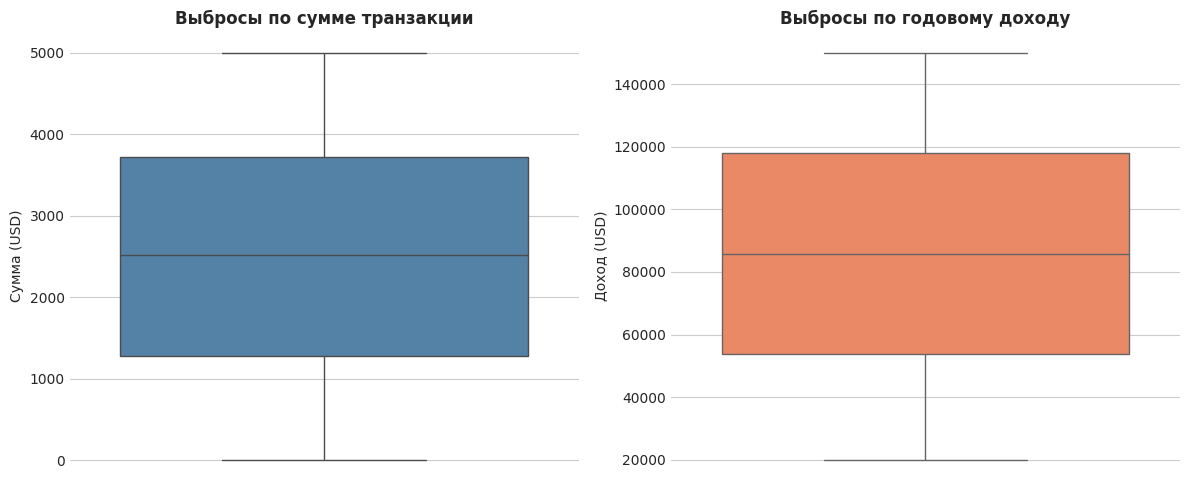


Мошеннические транзакции среди выбросов по сумме: 0


In [15]:
# Выявление выбросов методом IQR
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

# Анализ выбросов для суммы транзакции
outliers_amount, lb_amt, ub_amt = detect_outliers_iqr(df, 'Transaction_Amount')
print(f"Сумма транзакции:")
print(f"  Нижняя граница: {lb_amt:.2f}")
print(f"  Верхняя граница: {ub_amt:.2f}")
print(f"  Количество выбросов: {len(outliers_amount)} ({len(outliers_amount)/len(df)*100:.2f}%)")

# Анализ выбросов для годового дохода
outliers_income, lb_inc, ub_inc = detect_outliers_iqr(df, 'Customer_Income')
print(f"\nГодовой доход:")
print(f"  Нижняя граница: {lb_inc:.2f}")
print(f"  Верхняя граница: {ub_inc:.2f}")
print(f"  Количество выбросов: {len(outliers_income)} ({len(outliers_income)/len(df)*100:.2f}%)")

# Визуализация выбросов с помощью boxplot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(data=df, y='Transaction_Amount', ax=axes[0], color='steelblue')
axes[0].set_title('Выбросы по сумме транзакции', fontweight='bold')
axes[0].set_ylabel('Сумма (USD)')

sns.boxplot(data=df, y='Customer_Income', ax=axes[1], color='coral')
axes[1].set_title('Выбросы по годовому доходу', fontweight='bold')
axes[1].set_ylabel('Доход (USD)')

plt.tight_layout()
plt.show()

# Анализ выбросов среди мошеннических транзакций
fraud_outliers = outliers_amount[outliers_amount['Fraud_Flag'] == 1]
print(f"\nМошеннические транзакции среди выбросов по сумме: {len(fraud_outliers)}")

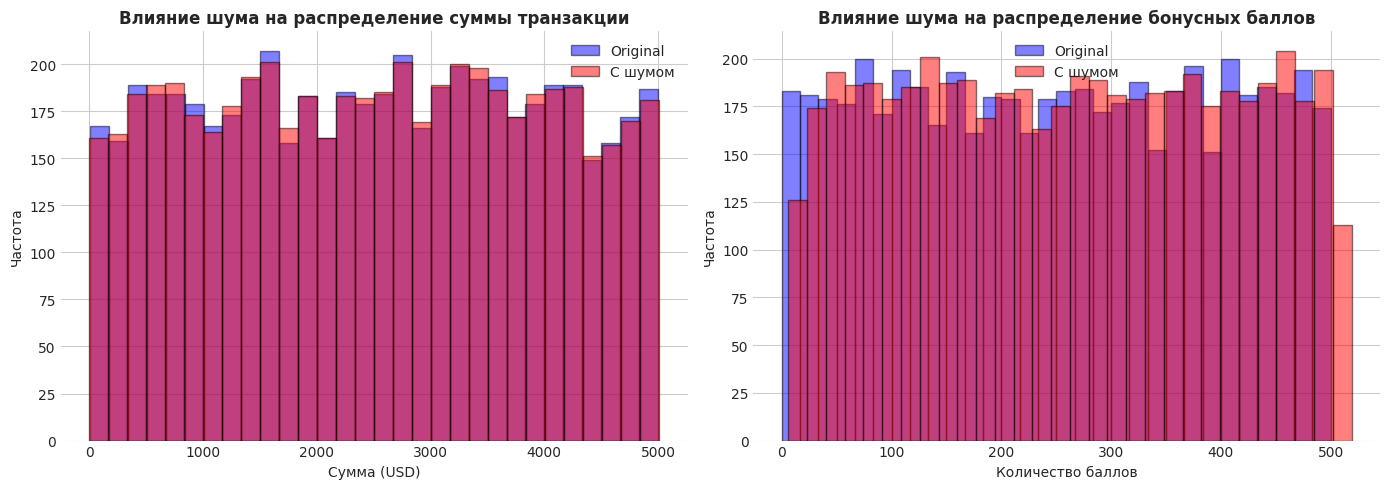

Стандартное отклонение original amount: 1426.75
Стандартное отклонение noisy amount: 1427.03
Среднее абсолютное изменение суммы: 11.3083


In [16]:
#2.10
np.random.seed(42)

# Добавление шума в признак 'Transaction_Amount' (гауссовский шум, 1% от стандартного отклонения)
def add_gaussian_noise(data, column, noise_level=0.01):
    noise = np.random.normal(0, noise_level * data[column].std(), len(data))
    noisy_data = data[column] + noise
    return noisy_data.clip(lower=0)  # Сумма не может быть отрицательной

# Добавление шума в признак 'Loyalty_Points_Earned' (пуассоновский шум)
def add_poisson_noise(data, column, noise_scale=0.05):
    noise = np.random.poisson(noise_scale * data[column].mean(), len(data))
    noisy_data = data[column] + noise
    return noisy_data.clip(lower=0)

# Создание копии датасета с шумом
df_noisy = df.copy()

# Добавление шума
df_noisy['Transaction_Amount_noisy'] = add_gaussian_noise(df, 'Transaction_Amount',
                                                           noise_level=0.01)
df_noisy['Loyalty_Points_Earned_noisy'] = add_poisson_noise(df, 'Loyalty_Points_Earned',
                                                             noise_scale=0.05)

# Визуализация влияния шума
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Сравнение распределений суммы
axes[0].hist(df['Transaction_Amount'], bins=30, alpha=0.5, label='Original',
             color='blue', edgecolor='black')
axes[0].hist(df_noisy['Transaction_Amount_noisy'], bins=30, alpha=0.5, label='С шумом',
             color='red', edgecolor='black')
axes[0].set_title('Влияние шума на распределение суммы транзакции', fontweight='bold')
axes[0].set_xlabel('Сумма (USD)')
axes[0].set_ylabel('Частота')
axes[0].legend()

# Сравнение распределений бонусных баллов
axes[1].hist(df['Loyalty_Points_Earned'], bins=30, alpha=0.5, label='Original',
             color='blue', edgecolor='black')
axes[1].hist(df_noisy['Loyalty_Points_Earned_noisy'], bins=30, alpha=0.5, label='С шумом',
             color='red', edgecolor='black')
axes[1].set_title('Влияние шума на распределение бонусных баллов', fontweight='bold')
axes[1].set_xlabel('Количество баллов')
axes[1].set_ylabel('Частота')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Стандартное отклонение original amount: {df['Transaction_Amount'].std():.2f}")
print(f"Стандартное отклонение noisy amount: {df_noisy['Transaction_Amount_noisy'].std():.2f}")
print(f"Среднее абсолютное изменение суммы: {(df_noisy['Transaction_Amount_noisy'] - df['Transaction_Amount']).abs().mean():.4f}")

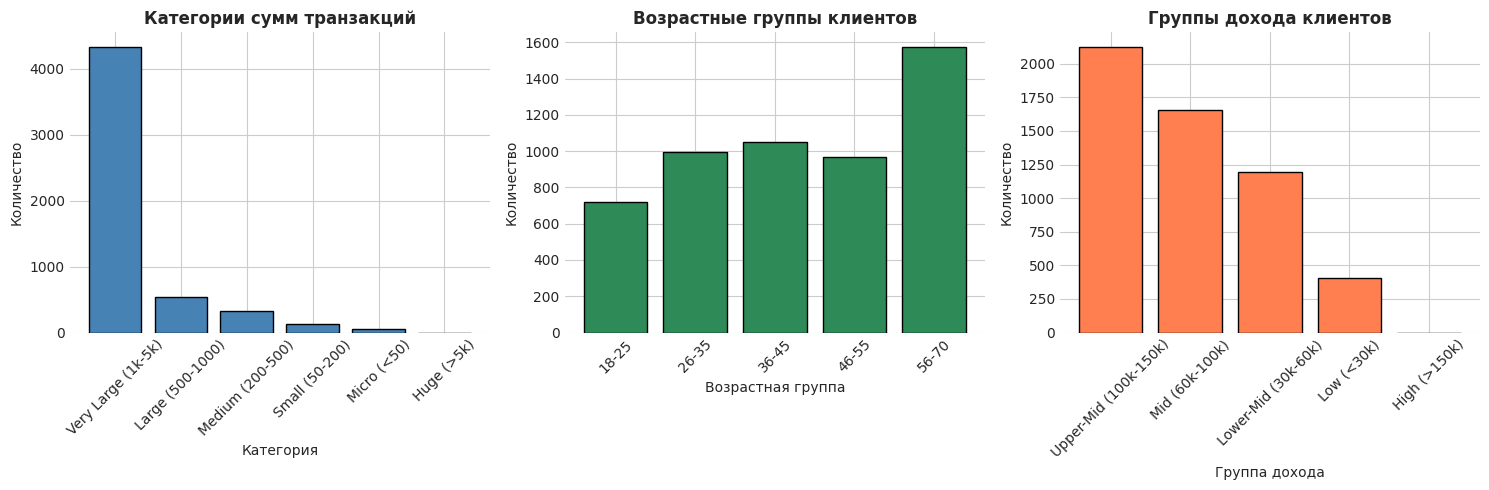

Распределение категорий сумм:
Amount_Category
Very Large (1k-5k)    4338
Large (500-1000)       543
Medium (200-500)       321
Small (50-200)         136
Micro (<50)             51
Huge (>5k)               0
Name: count, dtype: int64

Распределение возрастных групп:
Age_Group
18-25     718
26-35     994
36-45    1051
46-55     969
56-70    1576
Name: count, dtype: int64

Распределение групп дохода:
Income_Group
Upper-Mid (100k-150k)    2127
Mid (60k-100k)           1657
Lower-Mid (30k-60k)      1197
Low (<30k)                408
High (>150k)                0
Name: count, dtype: int64


In [17]:
# Анализ распределения суммы для создания категорий
amount_bins = [0, 50, 200, 500, 1000, 5000, float('inf')]
amount_labels = ['Micro (<50)', 'Small (50-200)', 'Medium (200-500)',
                 'Large (500-1000)', 'Very Large (1k-5k)', 'Huge (>5k)']
df['Amount_Category'] = pd.cut(df['Transaction_Amount'], bins=amount_bins,
                               labels=amount_labels, right=False)

# Категории возраста
age_bins = [18, 25, 35, 45, 55, 70]
age_labels = ['18-25', '26-35', '36-45', '46-55', '56-70']
df['Age_Group'] = pd.cut(df['Customer_Age'], bins=age_bins,
                         labels=age_labels, right=False)

# Категории дохода
income_bins = [0, 30000, 60000, 100000, 150000, float('inf')]
income_labels = ['Low (<30k)', 'Lower-Mid (30k-60k)', 'Mid (60k-100k)',
                 'Upper-Mid (100k-150k)', 'High (>150k)']
df['Income_Group'] = pd.cut(df['Customer_Income'], bins=income_bins,
                            labels=income_labels, right=False)

# Визуализация новых категориальных признаков
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Распределение категорий сумм
amount_counts = df['Amount_Category'].value_counts()
axes[0].bar(amount_counts.index, amount_counts.values, color='steelblue', edgecolor='black')
axes[0].set_title('Категории сумм транзакций', fontweight='bold')
axes[0].set_xlabel('Категория')
axes[0].set_ylabel('Количество')
axes[0].tick_params(axis='x', rotation=45)

# Распределение возрастных групп
age_counts = df['Age_Group'].value_counts().sort_index()
axes[1].bar(age_counts.index, age_counts.values, color='seagreen', edgecolor='black')
axes[1].set_title('Возрастные группы клиентов', fontweight='bold')
axes[1].set_xlabel('Возрастная группа')
axes[1].set_ylabel('Количество')
axes[1].tick_params(axis='x', rotation=45)

# Распределение групп дохода
income_counts = df['Income_Group'].value_counts()
axes[2].bar(income_counts.index, income_counts.values, color='coral', edgecolor='black')
axes[2].set_title('Группы дохода клиентов', fontweight='bold')
axes[2].set_xlabel('Группа дохода')
axes[2].set_ylabel('Количество')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("Распределение категорий сумм:")
print(df['Amount_Category'].value_counts())
print("\nРаспределение возрастных групп:")
print(df['Age_Group'].value_counts().sort_index())
print("\nРаспределение групп дохода:")
print(df['Income_Group'].value_counts())

In [18]:
# Приведение типов транзакций к единому формату
print("Уникальные значения Transaction_Type до нормализации:")
print(df['Transaction_Type'].unique())

# Для демонстрации – создаём маппинг на русские названия
transaction_mapping = {
    'Debit': 'Списание',
    'Credit': 'Зачисление'
}
df['Transaction_Type_RU'] = df['Transaction_Type'].map(transaction_mapping)

# Приведение статуса транзакции к единому регистру
df['Transaction_Status'] = df['Transaction_Status'].str.capitalize()

# Извлечение даты и времени из Transaction_Date
df['Transaction_Date'] = pd.to_datetime(df['Transaction_Date'])
df['Transaction_Year'] = df['Transaction_Date'].dt.year
df['Transaction_Month'] = df['Transaction_Date'].dt.month
df['Transaction_Day'] = df['Transaction_Date'].dt.day
df['Transaction_Hour'] = df['Transaction_Date'].dt.hour

# Создание признака "соотношение суммы к доходу"
df['Amount_to_Income_Ratio'] = df['Transaction_Amount'] / (df['Customer_Income'] / 12)

print("\nДанные после преобразований:")
display(df[['Transaction_Type', 'Transaction_Type_RU', 'Transaction_Status',
           'Transaction_Hour', 'Amount_to_Income_Ratio']].head())

# Анализ соотношения сумма/доход для мошеннических транзакций
fraud_ratio = df[df['Fraud_Flag'] == 1]['Amount_to_Income_Ratio'].mean()
legit_ratio = df[df['Fraud_Flag'] == 0]['Amount_to_Income_Ratio'].mean()
print(f"\nСреднее соотношение сумма/месячный доход для мошеннических транзакций: {fraud_ratio:.4f}")
print(f"Среднее соотношение сумма/месячный доход для легитимных транзакций: {legit_ratio:.4f}")

Уникальные значения Transaction_Type до нормализации:
['Debit' 'Credit']

Данные после преобразований:


,Transaction_Type,Transaction_Type_RU,Transaction_Status,Transaction_Hour,Amount_to_Income_Ratio
0,Debit,Списание,Failed,15,0.477062
1,Credit,Зачисление,Pending,22,0.010710
2,Credit,Зачисление,Failed,13,0.494668
3,Credit,Зачисление,Failed,16,0.123521
4,Credit,Зачисление,Failed,23,0.437728



Среднее соотношение сумма/месячный доход для мошеннических транзакций: nan
Среднее соотношение сумма/месячный доход для легитимных транзакций: nan


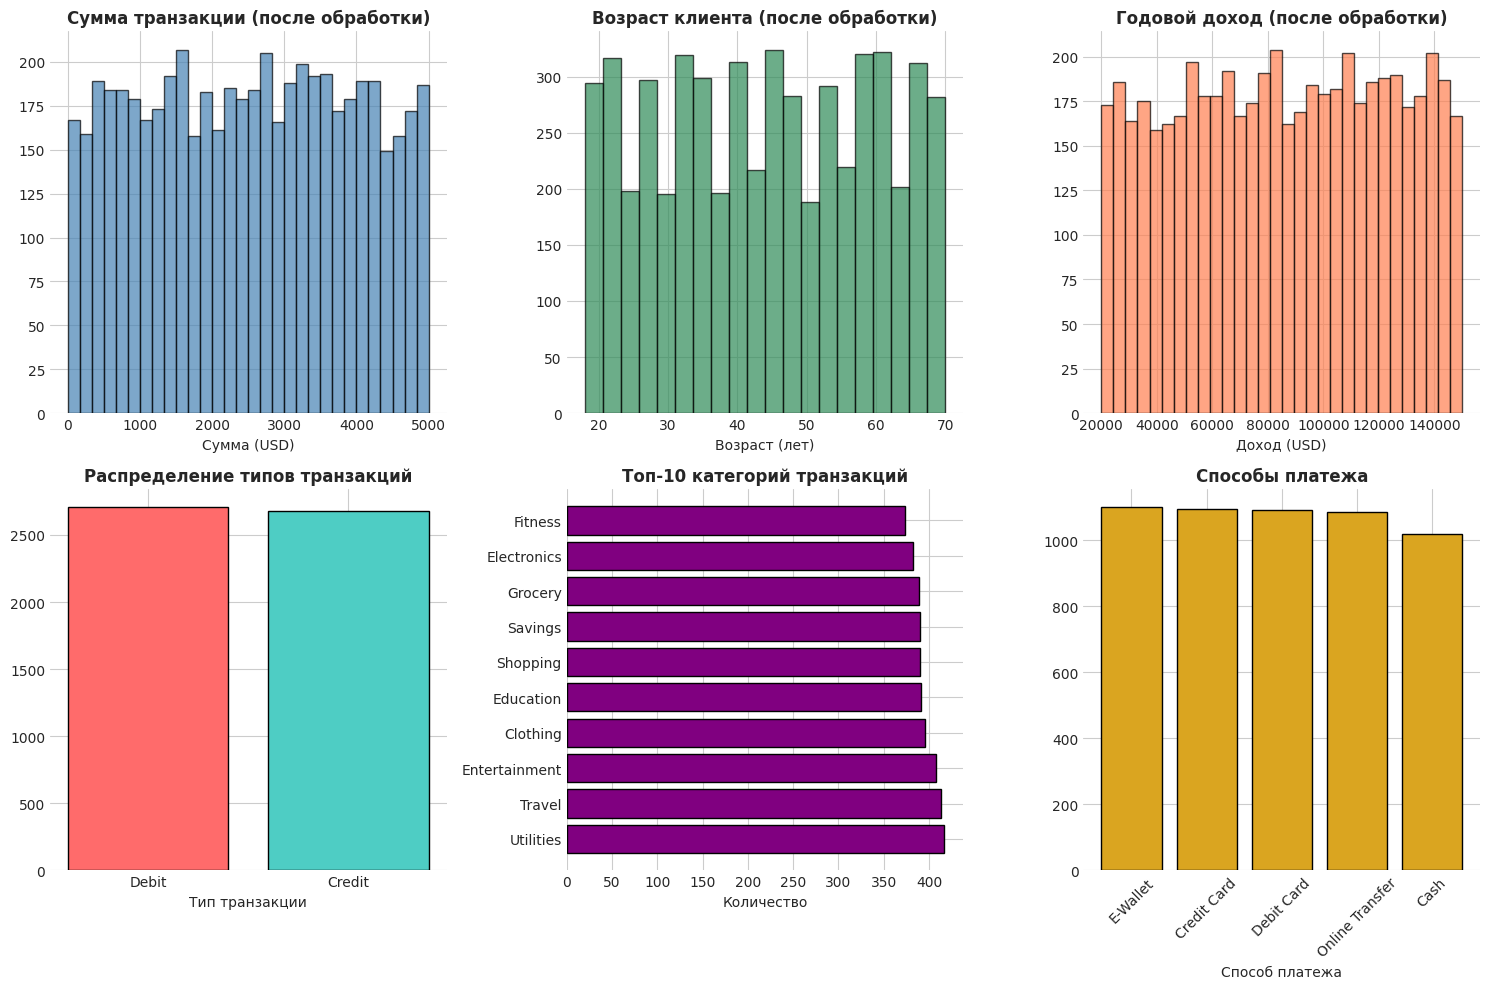

In [19]:
# Повторная визуализация основных гистограмм после всех трансформаций
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

# Исходные распределения (после обработки)
axes[0].hist(df['Transaction_Amount'], bins=30, alpha=0.7, color='steelblue', edgecolor='black')
axes[0].set_title('Сумма транзакции (после обработки)', fontweight='bold')
axes[0].set_xlabel('Сумма (USD)')

axes[1].hist(df['Customer_Age'], bins=20, alpha=0.7, color='seagreen', edgecolor='black')
axes[1].set_title('Возраст клиента (после обработки)', fontweight='bold')
axes[1].set_xlabel('Возраст (лет)')

axes[2].hist(df['Customer_Income'], bins=30, alpha=0.7, color='coral', edgecolor='black')
axes[2].set_title('Годовой доход (после обработки)', fontweight='bold')
axes[2].set_xlabel('Доход (USD)')

# Распределение по типам транзакций
type_counts = df['Transaction_Type'].value_counts()
axes[3].bar(type_counts.index, type_counts.values, color=['#FF6B6B', '#4ECDC4'], edgecolor='black')
axes[3].set_title('Распределение типов транзакций', fontweight='bold')
axes[3].set_xlabel('Тип транзакции')

# Распределение по категориям
category_counts = df['Category'].value_counts().head(10)
axes[4].barh(category_counts.index, category_counts.values, color='purple', edgecolor='black')
axes[4].set_title('Топ-10 категорий транзакций', fontweight='bold')
axes[4].set_xlabel('Количество')

# Распределение по способам платежа
payment_counts = df['Payment_Method'].value_counts()
axes[5].bar(payment_counts.index, payment_counts.values, color='goldenrod', edgecolor='black')
axes[5].set_title('Способы платежа', fontweight='bold')
axes[5].set_xlabel('Способ платежа')
axes[5].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [20]:
print("=== Категориальные признаки и их значения ===\n")

print(f"Тип транзакции (Transaction_Type): {df['Transaction_Type'].unique().tolist()}")
print(f"  Количество категорий: {df['Transaction_Type'].nunique()}")

print(f"\nПол (Customer_Gender): {df['Customer_Gender'].unique().tolist()}")
print(f"  Количество категорий: {df['Customer_Gender'].nunique()}")

print(f"\nКатегория (Category): {df['Category'].unique().tolist()}")
print(f"  Количество категорий: {df['Category'].nunique()}")

print(f"\nСпособ платежа (Payment_Method): {df['Payment_Method'].unique().tolist()}")
print(f"  Количество категорий: {df['Payment_Method'].nunique()}")

print(f"\nСтатус транзакции (Transaction_Status): {df['Transaction_Status'].unique().tolist()}")
print(f"  Количество категорий: {df['Transaction_Status'].nunique()}")

print(f"\nПрименение скидки (Discount_Applied): {df['Discount_Applied'].unique().tolist()}")
print(f"  Количество категорий: {df['Discount_Applied'].nunique()}")

=== Категориальные признаки и их значения ===

Тип транзакции (Transaction_Type): ['Debit', 'Credit']
  Количество категорий: 2

Пол (Customer_Gender): ['Others', 'Male', 'Female']
  Количество категорий: 3

Категория (Category): ['Transport', 'Grocery', 'Shopping', 'Healthcare', 'Entertainment', 'Savings', 'Clothing', 'Housing', 'Electronics', 'Education', 'Utilities', 'Fitness', 'Travel', 'Food']
  Количество категорий: 14

Способ платежа (Payment_Method): ['Online Transfer', 'Debit Card', 'E-Wallet', 'Credit Card', 'Cash']
  Количество категорий: 5

Статус транзакции (Transaction_Status): ['Failed', 'Pending', 'Success']
  Количество категорий: 3

Применение скидки (Discount_Applied): [True, False]
  Количество категорий: 2


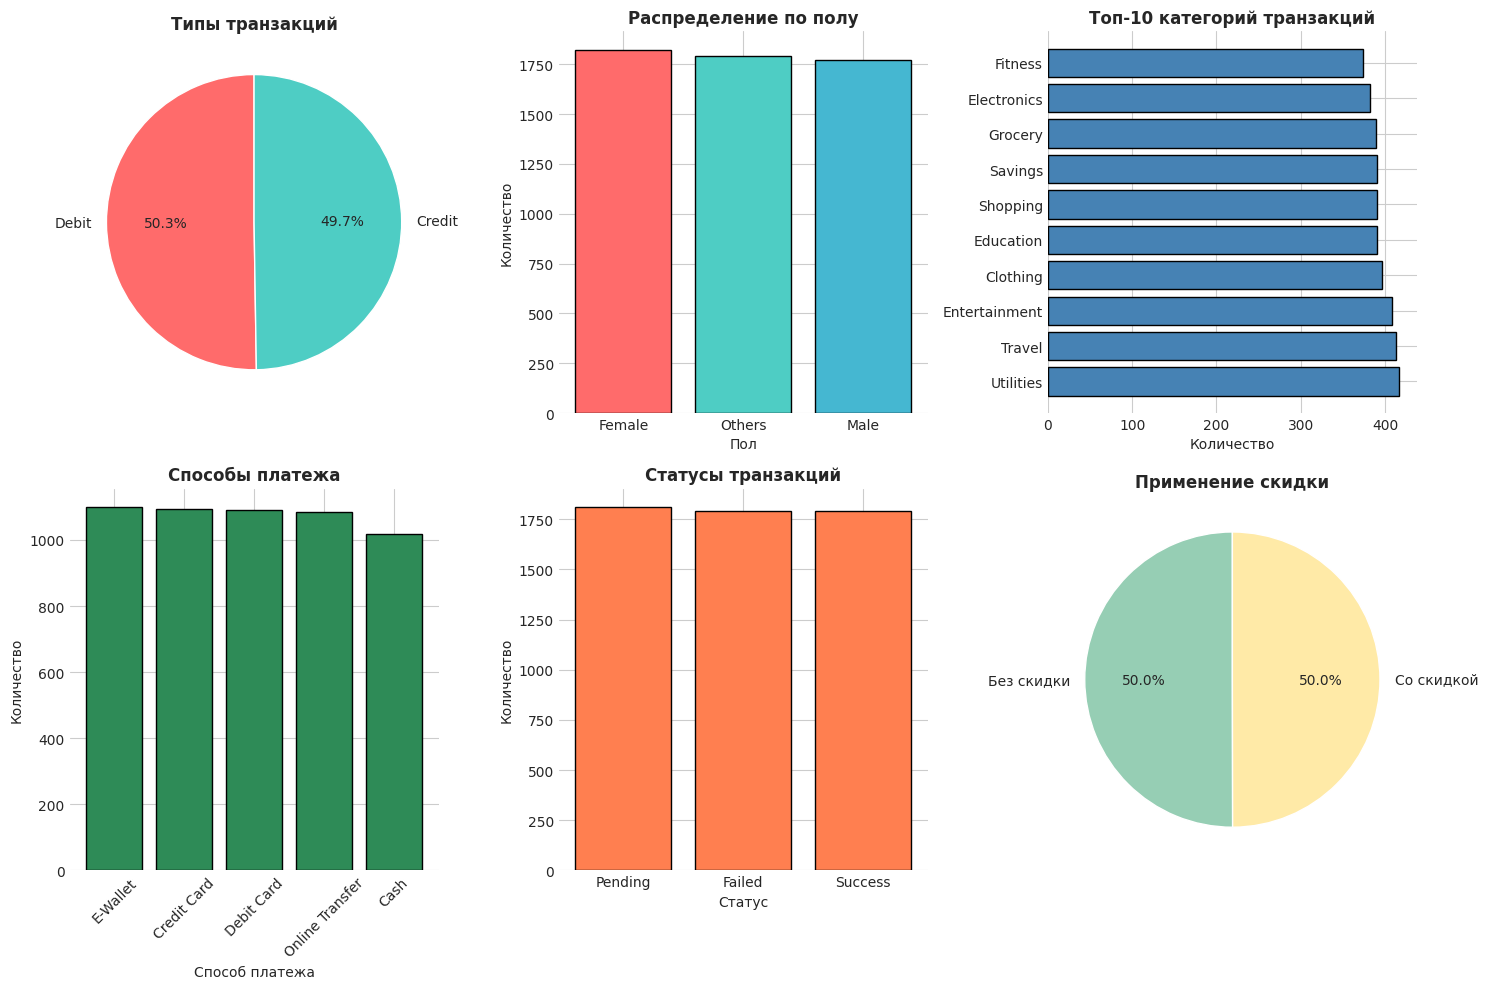

In [21]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# 1. Распределение типов транзакций
type_counts = df['Transaction_Type'].value_counts()
axes[0,0].pie(type_counts.values, labels=type_counts.index, autopct='%1.1f%%',
              colors=['#FF6B6B', '#4ECDC4'], startangle=90)
axes[0,0].set_title('Типы транзакций', fontweight='bold')

# 2. Распределение по полу
gender_counts = df['Customer_Gender'].value_counts()
axes[0,1].bar(gender_counts.index, gender_counts.values,
              color=['#FF6B6B', '#4ECDC4', '#45B7D1'], edgecolor='black')
axes[0,1].set_title('Распределение по полу', fontweight='bold')
axes[0,1].set_xlabel('Пол')
axes[0,1].set_ylabel('Количество')

# 3. Топ-10 категорий транзакций
category_counts = df['Category'].value_counts().head(10)
axes[0,2].barh(category_counts.index, category_counts.values, color='steelblue', edgecolor='black')
axes[0,2].set_title('Топ-10 категорий транзакций', fontweight='bold')
axes[0,2].set_xlabel('Количество')

# 4. Распределение способов платежа
payment_counts = df['Payment_Method'].value_counts()
axes[1,0].bar(payment_counts.index, payment_counts.values, color='seagreen', edgecolor='black')
axes[1,0].set_title('Способы платежа', fontweight='bold')
axes[1,0].set_xlabel('Способ платежа')
axes[1,0].set_ylabel('Количество')
axes[1,0].tick_params(axis='x', rotation=45)

# 5. Распределение статусов транзакций
status_counts = df['Transaction_Status'].value_counts()
axes[1,1].bar(status_counts.index, status_counts.values, color='coral', edgecolor='black')
axes[1,1].set_title('Статусы транзакций', fontweight='bold')
axes[1,1].set_xlabel('Статус')
axes[1,1].set_ylabel('Количество')

# 6. Применение скидки
discount_counts = df['Discount_Applied'].value_counts()
axes[1,2].pie(discount_counts.values, labels=['Без скидки', 'Со скидкой'],
              autopct='%1.1f%%', colors=['#96CEB4', '#FFEAA7'], startangle=90)
axes[1,2].set_title('Применение скидки', fontweight='bold')

plt.tight_layout()
plt.show()

In [22]:
from sklearn.preprocessing import LabelEncoder

# 1. Label Encoding для пола
le_gender = LabelEncoder()
df['Gender_Encoded'] = le_gender.fit_transform(df['Customer_Gender'])
print("Label Encoding для пола:")
print(dict(zip(le_gender.classes_, le_gender.transform(le_gender.classes_))))

# 2. Label Encoding для статуса транзакции
le_status = LabelEncoder()
df['Status_Encoded'] = le_status.fit_transform(df['Transaction_Status'])
print("\nLabel Encoding для статуса транзакции:")
print(dict(zip(le_status.classes_, le_status.transform(le_status.classes_))))

# 3. One-Hot Encoding для способа платежа
ohe_payment = pd.get_dummies(df['Payment_Method'], prefix='payment')
df = pd.concat([df, ohe_payment], axis=1)
print("\nOne-Hot Encoding для способа платежа добавлен")
print(f"Добавлено столбцов: {ohe_payment.shape[1]}")

# 4. Частотное кодирование для категорий транзакций
category_freq = df['Category'].value_counts(normalize=True)
df['Category_Freq_Encoded'] = df['Category'].map(category_freq)
print("\nЧастотное кодирование для категорий транзакций выполнено")
print(f"Пример частот: {category_freq.head().round(4)}")

Label Encoding для пола:
{'Female': np.int64(0), 'Male': np.int64(1), 'Others': np.int64(2)}

Label Encoding для статуса транзакции:
{'Failed': np.int64(0), 'Pending': np.int64(1), 'Success': np.int64(2)}

One-Hot Encoding для способа платежа добавлен
Добавлено столбцов: 5

Частотное кодирование для категорий транзакций выполнено
Пример частот: Category
Utilities        0.0774
Travel           0.0766
Entertainment    0.0757
Clothing         0.0735
Education        0.0726
Name: proportion, dtype: float64


Новая категория 'Is_Premium_Buyer':
Is_Premium_Buyer
0    5389
Name: count, dtype: int64

Доля премиум покупателей: 0.00%


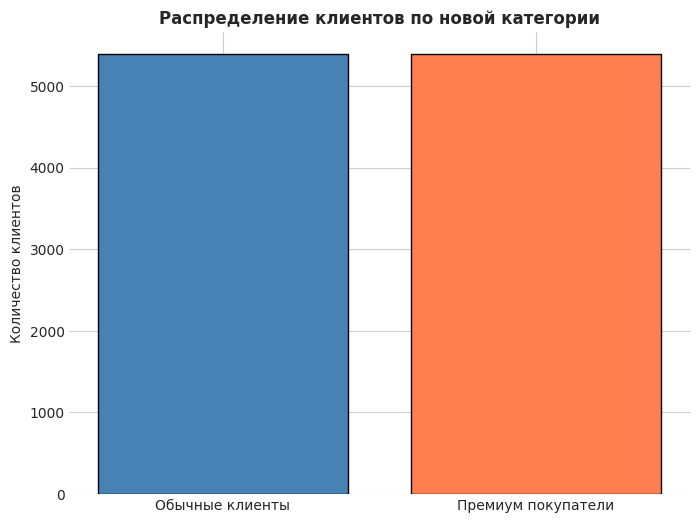

In [23]:
# Создание новой категории: "Премиум клиенты" (Высокий доход И Электроника)
df['Is_Premium_Buyer'] = ((df['Customer_Income'] > 150000) &
                          (df['Category'] == 'Electronics')).astype(int)

print("Новая категория 'Is_Premium_Buyer':")
print(df['Is_Premium_Buyer'].value_counts())
print(f"\nДоля премиум покупателей: {df['Is_Premium_Buyer'].mean()*100:.2f}%")

# Визуализация
plt.figure(figsize=(8, 6))
premium_counts = df['Is_Premium_Buyer'].value_counts()
plt.bar(['Обычные клиенты', 'Премиум покупатели'], premium_counts.values,
        color=['steelblue', 'coral'], edgecolor='black')
plt.title('Распределение клиентов по новой категории', fontweight='bold')
plt.ylabel('Количество клиентов')
plt.show()